# How the same 95% Interval Can Mean Different Things... and lead to different decisions!

---
**file name:** L1_fileA_Prediction_Intervals_Three_Meanings.ipynb

Part of Lecture 1 - first notebook

**Instructor:** Alice Cicirello

**Generated for Training school scientific machine learning for digital twins**


**The first draft version of the notebook was generated using Anthropic's Claude**

**Date**: September 2026

**Last Modifications and checks made by Alice Cicirello on: 5/09/2026**

---
### The meaning of a prediction interval

Engineers tend to report a number with an error bar. 
A report that says

$$\hat{y}(x_\star) = 31.1 \;\pm\; 1.5 \quad (\text{95\% interval})$$

*feels* complete.

But an interval is a **summary of assumptions**, not a fact about the
Case. 

Two engineers can hand you the **identical** $\pm 1.5$ and mean completely
different things by it — and a third can hand you a *narrower* interval that is simply
**wrong**.

In this notebook we build one concrete engineering prediction problem and solve it three
ways. Each produces a 95% interval.

It will be shown that:

| Interval | What its width reflects | Honest? | What further data does | Correct engineering decision |
|---|---|---|---|---|
| **A — Aleatoric** | irreducible measurement noise | ✅ yes | *nothing*, it stays wide (or it changes by reaching the correct width) | trust it; redesign for the real margin |
| **B — Epistemic** | too few data points | ✅ yes | *shrinks* it | don't redesign yet — **measure more** |
| **C — Model-form omitted** | only sensor precision | ❌ no | nothing (you never find out) | **do not trust it** — it is narrow *and* wrong |

> **A and B produce the *same width* yet justify *opposite* actions.
> C produces a *narrower* width that hides a dangerous error.**

We finish by asking the natural follow-up: *can't calibration metrics
(coverage, NLL, ECE) just tell me which interval to trust?* The answer is a careful
**"partly"** — and understanding why is the real lesson.

## 1. The problem: predicting a response at an untested operating point

A component's response $y$ (say a peak stress, a deflection, a temperature) depends on an
operating variable $x$ (a load, a speed, a flow rate). 

The **true** physics is *mildly
nonlinear* and described by a **true model**:

$$y = f(x) + \varepsilon, \qquad f(x) = 2 + x + 0.15\,x^2 .$$

with $\varepsilon$ being the noise in the observations 

**Challenge**

We can **test** the component on a rig over the range $x \in [0, 10]$.

But the component will
actually be **operated at $x_\star = 11$** — just *beyond* the tested range 

AND there is a
safety limit

$$y_\text{allow} = 30.$$

The **engineering question** is a simple go / no-go:

> *Will the response at the operating point exceed the allowable, and how sure are we?*


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
from scipy.stats import norm

rng = np.random.default_rng(0)

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

# Colour code the three uncertainty stories throughout the notebook
C_ALE = "#1b9e77"   # A: aleatoric  (green-teal)
C_EPI = "#d95f02"   # B: epistemic  (orange)
C_MOD = "#7570b3"   # C: model-form (purple)
C_TRUTH = "#111111"

# ---- the true system ------------------------------------------------
def f_true(x):
    x = np.asarray(x, float)
    return 2.0 + 1.0 * x + 0.15 * x**2

X_LO, X_HI = 0.0, 10.0     # rig test range
X_STAR     = 11.0          # operating point (UNTESTED)
Y_ALLOW    = 30.0          # allowable response
W_TARGET   = 1.5           # target 95% half-width for the A-vs-B headline
Z95        = norm.ppf(0.975)   # 1.96

print(f"True response at operating point x*={X_STAR}: f(x*) = {f_true(X_STAR):.2f}")
print(f"Allowable                                    : {Y_ALLOW:.2f}")
print(f"=> The system TRULY exceeds the allowable by {f_true(X_STAR)-Y_ALLOW:.2f}"
      f"  (a real, unsafe condition).")

True response at operating point x*=11.0: f(x*) = 31.15
Allowable                                    : 30.00
=> The system TRULY exceeds the allowable by 1.15  (a real, unsafe condition).


## 2. One probabilistic tool, used three ways: Bayesian linear regression

To keep the *only* difference between the three stories the **uncertainty bookkeeping**
(not the algorithm), we fit every case with the same estimator: **Bayesian Linear
Regression (BLR)** with polynomial features 

**Note that in this script we will just use the final expression of the predictive distribution that would be yield by using BLR, without going through all the steps of its derivation - its justification and steps will be discussed in the next notebook L1_fileB**

For features $\boldsymbol\phi(x)$,

known (zero-mean Gaussian) noise
variance $\sigma^2$,

and a vague Gaussian prior

the predictive distribution at a new $x$ is Gaussian with

$$\underbrace{\operatorname{Var}[y\mid x]}_{\text{total}}
 = \underbrace{\boldsymbol\phi(x)^\top \boldsymbol\Sigma\, \boldsymbol\phi(x)}_{\text{epistemic (parameters)}}
 \; + \; \underbrace{\sigma^2}_{\text{aleatoric (noise)}} .$$

This one equation already describes the uncertainty effects: 

the **epistemic** term shrinks as you
add data (it depends on $\boldsymbol\Sigma$, the parameter covariance); 

the **aleatoric**
term $\sigma^2$ does **not**.

What is *missing* from the equation — **model-form error**,
the possibility that $\boldsymbol\phi$ is the wrong shape — is exactly what sinks case C.

In [2]:
def design(x, degree):
    '''Polynomial feature (Vandermonde) matrix: columns 1, x, x^2, ...'''
    return np.vander(np.atleast_1d(np.asarray(x, float)), degree + 1, increasing=True)

def blr_fit(x, y, degree, sigma, tau=1e6):
    '''Bayesian linear regression, known noise sigma, vague Gaussian prior N(0, tau^2 I).'''
    Phi = design(x, degree)
    A   = Phi.T @ Phi / sigma**2 + np.eye(degree + 1) / tau**2
    Sig = inv(A)
    mu  = Sig @ Phi.T @ y / sigma**2
    return {"mu": mu, "Sigma": Sig, "degree": degree, "sigma": sigma}

def blr_predict(model, x):
    '''Return predictive mean, total var, epistemic var, aleatoric var.'''
    Phi  = design(x, model["degree"])
    mean = Phi @ model["mu"]
    epi  = np.einsum("ij,jk,ik->i", Phi, model["Sigma"], Phi)   # phi^T Sigma phi
    ale  = np.full_like(mean, model["sigma"]**2)
    return mean, epi + ale, epi, ale

def q_ratio(x_train, degree, x0, tau=1e6):
    '''Epistemic-to-noise ratio q = phi(x0)^T (Phi^T Phi)^-1 phi(x0) at a point (vague prior).'''
    Phi = design(x_train, degree)
    P0  = design(x0, degree)
    M   = inv(Phi.T @ Phi + np.eye(degree + 1) / tau**2)
    return float((P0 @ M @ P0.T).item())

## 3. Three datasets, three different problems

We now build the three datasets. 

The **key trick**: we choose the sensor noise in cases A
and B so that both produce **exactly** the same 95% half-width ($\pm 1.5$) at the operating
point — **but for entirely different reasons**.

- **Case A — a well-characterised system.** The correct (quadratic) model, a *lot* of rig
  data (300 points), and a *genuinely noisy* sensor. The $\pm1.5$ is almost **all
  $\sigma^2$**: irreducible measurement noise.
- **Case B — a data-starved system.** The correct (quadratic) model, a *precise* sensor,
  but only **5** rig points, all clustered in $[0,6]$. Predicting out at $x_\star=11$ is an
  extrapolation the sparse data barely constrains: the $\pm1.5$ is almost **all epistemic**.
- **Case C — a mis-modelled system.** A *precise* sensor and *plenty* of data, but the
  engineer assumes a **straight-line** ($y=a+bx$) model. It reports only its sensor
  precision as uncertainty — and says nothing about being the wrong shape.

In [3]:
# ---- Case A : aleatoric-dominated -------------------------------------------------
xA = rng.uniform(X_LO, X_HI, 300)
qA = q_ratio(xA, degree=2, x0=X_STAR)                 # tiny: lots of data, correct form
sigA = (W_TARGET / Z95) / np.sqrt(qA + 1.0)           # noise scaled to hit +/-1.5 half-width
yA = f_true(xA) + rng.normal(0, sigA, xA.size)
modA = blr_fit(xA, yA, degree=2, sigma=sigA)

# ---- Case B : epistemic-dominated -------------------------------------------------
xB = np.array([0.5, 2.0, 3.5, 5.0, 6.0])              # only 5 points, none past x=6
qB = q_ratio(xB, degree=2, x0=X_STAR)                 # huge: sparse data + extrapolation
sigB = (W_TARGET / Z95) / np.sqrt(qB + 1.0)           # precise sensor, scaled to same +/-1.5
yB = f_true(xB) + rng.normal(0, sigB, xB.size)
modB = blr_fit(xB, yB, degree=2, sigma=sigB)

# ---- Case C : model-form error, precise sensor ------------------------------------
sigC = 0.10                                           # high-precision sensor (as reported)
xC = rng.uniform(X_LO, X_HI, 300)
yC = f_true(xC) + rng.normal(0, sigC, xC.size)
modC = blr_fit(xC, yC, degree=1, sigma=sigC)          # WRONG model form: straight line

print(f"Case A  noise sigma_A = {sigA:.3f}   (moderate, honestly reported)")
print(f"Case B  noise sigma_B = {sigB:.3f}   (precise sensor)")
print(f"Case C  noise sigma_C = {sigC:.3f}   (precise sensor)")
print()
print(f"Epistemic share of the +/-1.5 interval, q/(q+1):")
print(f"   Case A : {qA/(qA+1):6.1%}   -> width is almost all measurement noise")
print(f"   Case B : {qB/(qB+1):6.1%}   -> width is almost all parameter ignorance")

Case A  noise sigma_A = 0.746   (moderate, honestly reported)
Case B  noise sigma_B = 0.092   (precise sensor)
Case C  noise sigma_C = 0.100   (precise sensor)

Epistemic share of the +/-1.5 interval, q/(q+1):
   Case A :   4.9%   -> width is almost all measurement noise
   Case B :  98.6%   -> width is almost all parameter ignorance


## 4. The results: identical intervals, different reasons (and consequent decisions)

Below, all three fits are drawn on the same axes. 

**Check the interval at the operating point
$x_\star = 11$ (dashed vertical line)**:

- **A and B intervals are the same width (mean is different!)** — but A's is fat *everywhere* (noise), while B's
  is *pinched where the data live* and *flares out* into the extrapolation (ignorance).
- **C's interval is a thin ribbon** that sails confidently *below the allowable* — and
  *below the truth*.

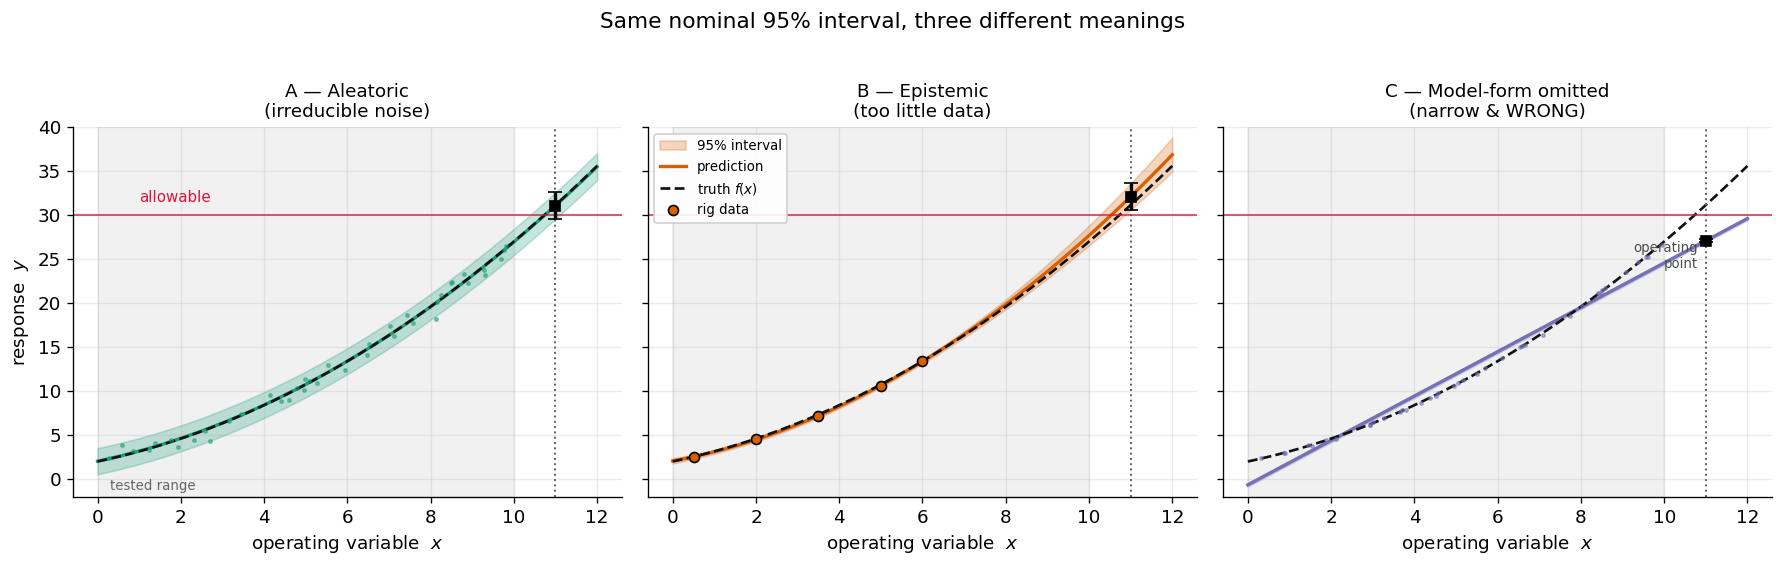

In [4]:
xg = np.linspace(X_LO, X_STAR + 1.0, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
specs = [
    ("A — Aleatoric\n(irreducible noise)", modA, xA, yA, C_ALE),
    ("B — Epistemic\n(too little data)",    modB, xB, yB, C_EPI),
    ("C — Model-form omitted\n(narrow & WRONG)", modC, xC, yC, C_MOD),
]
for ax, (title, mod, xt, yt, col) in zip(axes, specs):
    mean, var, _, _ = blr_predict(mod, xg)
    sd = np.sqrt(var)
    ax.fill_between(xg, mean - Z95*sd, mean + Z95*sd, color=col, alpha=0.25,
                    label="95% interval")
    ax.plot(xg, mean, color=col, lw=2, label="prediction")
    ax.plot(xg, f_true(xg), "--", color=C_TRUTH, lw=1.6, label="truth $f(x)$")
    # training data (subsample A/C so we can see them)
    if xt.size > 40:
        idx = rng.choice(xt.size, 40, replace=False)
        ax.plot(xt[idx], yt[idx], ".", color=col, ms=4, alpha=0.5)
    else:
        ax.plot(xt, yt, "o", color=col, ms=6, mec="k", label="rig data")
    ax.axvline(X_STAR, color="0.4", ls=":", lw=1.2)
    ax.axhline(Y_ALLOW, color="crimson", ls="-", lw=1.2, alpha=0.7)
    ax.axvspan(X_LO, X_HI, color="0.85", alpha=0.35, zorder=0)
    # operating-point interval marker
    m0, v0, _, _ = blr_predict(mod, X_STAR)
    ax.errorbar(X_STAR, m0[0], yerr=Z95*np.sqrt(v0[0]), fmt="s", color="k",
                ms=6, capsize=4, lw=2, zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("operating variable  $x$")
    ax.set_ylim(-2, 40)
axes[0].set_ylabel("response  $y$")
axes[0].text(1, 31.5, "allowable", color="crimson", fontsize=9)
axes[0].text(0.3, -1.2, "tested range", color="0.4", fontsize=8)
axes[2].text(X_STAR-0.2, 24, "operating\npoint", ha="right", color="0.3", fontsize=8)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Same nominal 95% interval, three different meanings", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Let's decompose the three intervals
The same three intervals, now decomposed into their **aleatoric** and **epistemic** parts at
the operating point. 

A fourth bar exposes what C's bookkeeping *left out*: its **model-form
error** — the gap between where its straight line predicts and where the truth actually is.

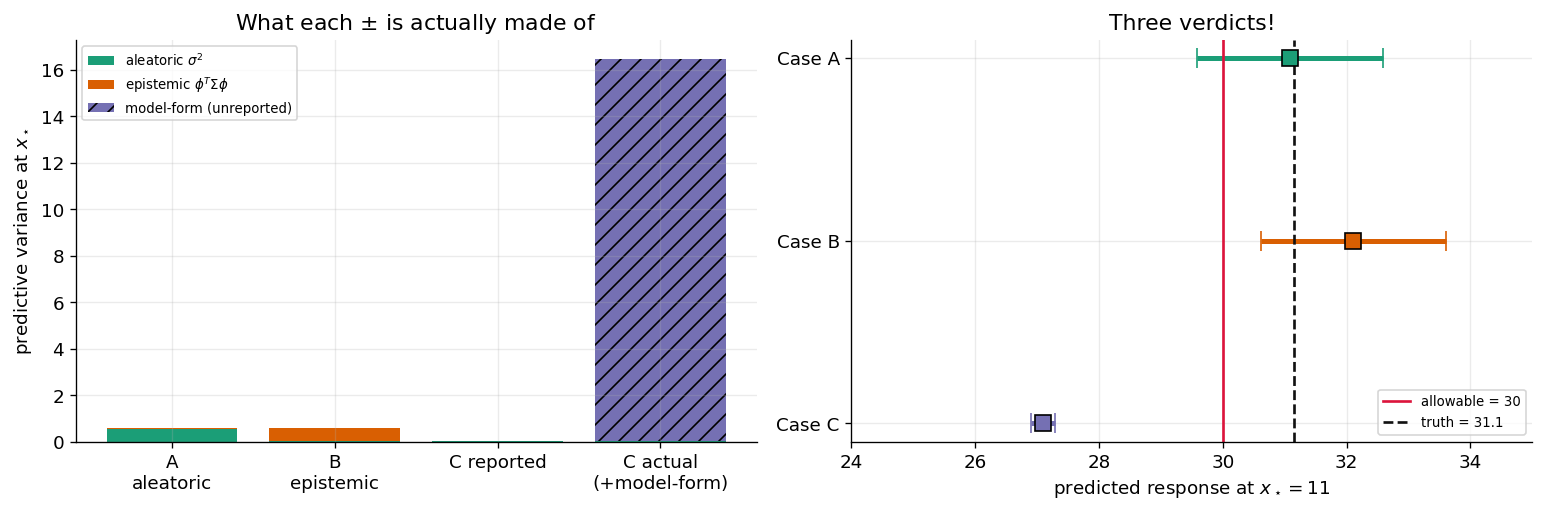

Case A: mean = 31.09,  95% half-width = +/-1.50
Case B: mean = 32.11,  95% half-width = +/-1.50
Case C: mean = 27.09,  95% half-width = +/-0.20

C's straight line misses the truth by 4.06 — roughly 21x its own reported half-width.


In [5]:
def report(mod, name):
    mean, var, epi, ale = blr_predict(mod, X_STAR)
    return dict(name=name, mean=float(mean[0]), sd=float(np.sqrt(var[0])),
                hw=float(Z95*np.sqrt(var[0])), epi=float(epi[0]), ale=float(ale[0]))

rA, rB, rC = report(modA, "A"), report(modB, "B"), report(modC, "C")
truth_star = f_true(X_STAR)

# C's hidden model-form error = squared bias of its mean at x*
bias_C   = truth_star - rC["mean"]
modform_var_C = bias_C**2     # the variance-equivalent C never reported

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# ---- left: stacked variance decomposition -------------------------------
labels = ["A\naleatoric", "B\nepistemic", "C reported", "C actual\n(+model-form)"]
ale_parts = [rA["ale"], rB["ale"], rC["ale"], rC["ale"]]
epi_parts = [rA["epi"], rB["epi"], rC["epi"], rC["epi"]]
mod_parts = [0, 0, 0, modform_var_C]
x = np.arange(4)
ax1.bar(x, ale_parts, color=C_ALE, label="aleatoric $\\sigma^2$")
ax1.bar(x, epi_parts, bottom=ale_parts, color=C_EPI, label="epistemic $\\phi^T\\Sigma\\phi$")
ax1.bar(x, mod_parts, bottom=np.array(ale_parts)+np.array(epi_parts),
        color=C_MOD, hatch="//", label="model-form (unreported)")
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("predictive variance at $x_\\star$")
ax1.set_title("What each $\\pm$ is actually made of")
ax1.legend(fontsize=8)

# ---- right: the decision picture at the operating point ------------------
names = ["A", "B", "C"]
means = [rA["mean"], rB["mean"], rC["mean"]]
hws   = [rA["hw"], rB["hw"], rC["hw"]]
cols  = [C_ALE, C_EPI, C_MOD]
y = np.arange(3)[::-1]
for yi, mi, hi, ci, ni in zip(y, means, hws, cols, names):
    ax2.errorbar(mi, yi, xerr=hi, fmt="s", ms=10, capsize=6, lw=3,
                 color=ci, mfc=ci, mec="k", ls="none")
ax2.axvline(Y_ALLOW, color="crimson", lw=1.6, label="allowable = 30")
ax2.axvline(truth_star, color=C_TRUTH, ls="--", lw=1.6, label=f"truth = {truth_star:.1f}")
ax2.set_yticks(y); ax2.set_yticklabels([f"Case {n}" for n in names])
ax2.set_xlabel("predicted response at $x_\\star = 11$")
ax2.set_title("Three verdicts!")
ax2.set_xlim(24, 35)
ax2.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

for r in (rA, rB, rC):
    print(f"Case {r['name']}: mean = {r['mean']:5.2f},  95% half-width = +/-{r['hw']:.2f}")
print(f"\nC's straight line misses the truth by {bias_C:.2f} "
      f"— roughly {abs(bias_C)/rC['hw']:.0f}x its own reported half-width.")

## 5. From interval TO different decisions!

Turn each interval into the actual engineering quantity:

the **probability that the operating
response exceeds the allowable**, $P(y_\star > 30)$ under each predictive distribution.

In [6]:
def p_exceed(mod):
    mean, var, _, _ = blr_predict(mod, X_STAR)
    return float(1 - norm.cdf(Y_ALLOW, loc=mean[0], scale=np.sqrt(var[0])))

rows = [
    ("A  aleatoric",     modA, "irreducible noise",
     "Real margin problem. Interval WILL NOT shrink.\n     -> Redesign / accept the margin."),
    ("B  epistemic",     modB, "too few data",
     "Might be unsafe, but we are data-starved.\n     -> Collect more rig data FIRST (interval will shrink)."),
    ("C  model-form",    modC, "sensor precision only",
     "Says 'safe' with near-certainty.\n     -> WRONG: the true response exceeds the allowable."),
]
print(f"{'Case':<16}{'95% half-width':>15}{'P(exceed allow.)':>19}   Decision")
print("-" * 100)
for name, mod, _, decision in rows:
    m, v, _, _ = blr_predict(mod, X_STAR)
    hw = Z95*np.sqrt(v[0])
    print(f"{name:<16}{'+/-'+format(hw,'.2f'):>15}{p_exceed(mod):>18.1%}   {decision}")
print("-" * 100)
print(f"Ground truth: response = {f_true(X_STAR):.1f} > allowable = {Y_ALLOW:.0f}  -> genuinely UNSAFE")

Case             95% half-width   P(exceed allow.)   Decision
----------------------------------------------------------------------------------------------------
A  aleatoric            +/-1.50             92.2%   Real margin problem. Interval WILL NOT shrink.
     -> Redesign / accept the margin.
B  epistemic            +/-1.50             99.7%   Might be unsafe, but we are data-starved.
     -> Collect more rig data FIRST (interval will shrink).
C  model-form           +/-0.20              0.0%   Says 'safe' with near-certainty.
     -> WRONG: the true response exceeds the allowable.
----------------------------------------------------------------------------------------------------
Ground truth: response = 31.1 > allowable = 30  -> genuinely UNSAFE


Read the table carefully:

- **A and B report the identical $\pm 1.5$ and the identical ~93% chance of exceedance** —
  yet the right action is *opposite*.

   For **A** the width is a fact of the sensor: more
  testing changes nothing, so you **act on the margin now**.

  For **B** the width is an
  *admission of ignorance*: the responsible move is to **gather more data before deciding** before the interval will shrik.
  
- **C reports a *narrower* interval and ~0% exceedance — and is dangerously wrong.** By
  reporting only its sensor precision it omitted the one uncertainty that mattered: *is my
  model even the right shape?*

> The number $\pm1.5$ did not tell you which case you were in. **You have to know which
> uncertainty sources went into it.**

## 6. "Reducible?" — add data and observe the interval

How to understand the difference between A and B: 
pour in more data and observe the
interval! 

Epistemic uncertainty (B) **reduces**.

Aleatoric uncertainty (A) is a **floor** you cannot cross. 

C is not shown here — no amount of *this* data fixes a wrong model.

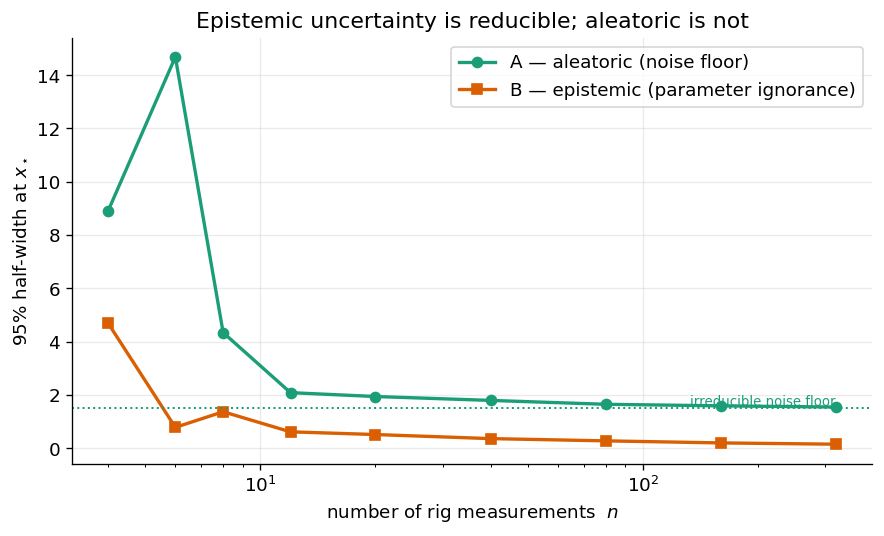

In [7]:
ns = np.array([4, 6, 8, 12, 20, 40, 80, 160, 320])
hw_A, hw_B = [], []
sig_A_case, sig_B_case = 0.765, 0.05     # fixed sensor noise in each case

for n in ns:
    xa = rng.uniform(X_LO, X_HI, n)
    ma = blr_fit(xa, f_true(xa) + rng.normal(0, sig_A_case, n), 2, sig_A_case)
    _, va, _, _ = blr_predict(ma, X_STAR); hw_A.append(Z95*np.sqrt(va[0]))

    xb = rng.uniform(X_LO, 6.0, n)          # B keeps sampling only in [0,6]
    mb = blr_fit(xb, f_true(xb) + rng.normal(0, sig_B_case, n), 2, sig_B_case)
    _, vb, _, _ = blr_predict(mb, X_STAR); hw_B.append(Z95*np.sqrt(vb[0]))

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(ns, hw_A, "o-", color=C_ALE, lw=2, label="A — aleatoric (noise floor)")
ax.plot(ns, hw_B, "s-", color=C_EPI, lw=2, label="B — epistemic (parameter ignorance)")
ax.axhline(Z95*sig_A_case, color=C_ALE, ls=":", lw=1.2)
ax.text(ns[-1], Z95*sig_A_case*1.08, "irreducible noise floor", color=C_ALE,
        ha="right", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("number of rig measurements  $n$")
ax.set_ylabel("95% half-width at $x_\\star$")
ax.set_title("Epistemic uncertainty is reducible; aleatoric is not")
ax.legend()
fig.tight_layout()
plt.show()

## 7. Some of you might think of using calibration to understand which one to trust - would it be enough?

A natural reaction: 
*if I hold out some test data and check whether my intervals
are "honest", can I understand if I am in Case A, B or C?* 

**Calibration metrics** do exactly this — they compare
**reported** uncertainty against **observed** error frequencies:

- **Coverage** — of the points inside a nominal 95% interval, what fraction actually land
  there? (Want ≈ 95%.)
- **Negative log-likelihood (NLL)** — how probable is the observed data under the predictive
  distribution? (Lower is better; punishes both over- and under-confidence.)
- **Expected Calibration Error (ECE)** — averaged over *all* nominal levels, how far is
  empirical coverage from nominal? (Want ≈ 0.)

These are essential and you should always compute them. 

But here is the catch this notebook
is built to expose:

In [8]:
LEVELS = np.linspace(0.05, 0.95, 19)

def band_hit(mod, x, y, level):
    m, v, _, _ = blr_predict(mod, x)
    z = norm.ppf(0.5 + level/2); sd = np.sqrt(v)
    return (y >= m - z*sd) & (y <= m + z*sd)

def nll_pts(mod, x, y):
    m, v, _, _ = blr_predict(mod, x)
    return 0.5*np.log(2*np.pi*v) + (y - m)**2 / (2*v)

def assess(sample_train, degree, sigma, sample_test, n_campaigns=250, n_test=800):
    '''Repeat a whole rig CAMPAIGN many times; average calibration of the METHOD.

    Calibration is a property of a procedure over repeated data, so we redraw the
    engineer's data campaign n_campaigns times and pool the fresh-test outcomes.'''
    hits = np.zeros(LEVELS.size); cov95 = 0.0; nll_tot = 0.0; ntot = 0
    for _ in range(n_campaigns):
        xt = sample_train(); yt = f_true(xt) + rng.normal(0, sigma, xt.size)
        mod = blr_fit(xt, yt, degree, sigma)
        xe = sample_test(); ye = f_true(xe) + rng.normal(0, sigma, xe.size)
        for j, p in enumerate(LEVELS):
            hits[j] += band_hit(mod, xe, ye, p).sum()
        cov95   += band_hit(mod, xe, ye, 0.95).sum()
        nll_tot += nll_pts(mod, xe, ye).sum()
        ntot    += xe.size
    emp = hits / ntot
    ece = float(np.mean(np.abs(emp - LEVELS)))
    return dict(emp=emp, cov95=cov95/ntot, nll=nll_tot/ntot, ece=ece)

# Samplers: each engineer can only HOLD OUT data where they actually tested (rig range).
smp_A = lambda: rng.uniform(X_LO, X_HI, 300)             # A: dense over [0,10]
smp_B = lambda: rng.uniform(X_LO, 6.0, 5)                # B: 5 points in [0,6]
smp_C = lambda: rng.uniform(X_LO, X_HI, 300)             # C: dense over [0,10]
test_rig = lambda: rng.uniform(X_LO, X_HI, 800)          # held-out RIG data (available)
test_op  = lambda: rng.uniform(10.0, 12.0, 800)          # operating range (NO data in practice)

resA  = assess(smp_A, 2, sigA, test_rig)
resB  = assess(smp_B, 2, sigB, test_rig)
resC  = assess(smp_C, 1, sigC, test_rig)     # C checked where data exists: the rig range
resCo = assess(smp_C, 1, sigC, test_op)      # C at operating range: only if data existed

results = [
    ("A  aleatoric  (rig range)",  resA,  C_ALE, "-"),
    ("B  epistemic  (rig range)",  resB,  C_EPI, "-"),
    ("C  model-form (rig range)",  resC,  C_MOD, "-"),
    ("C  model-form (operating)",  resCo, "crimson", "--"),
]
print(f"{'case':<30}{'coverage(95%)':>15}{'NLL':>10}{'ECE':>10}")
print("-"*65)
for name, r, col, ls in results:
    print(f"{name:<30}{r['cov95']:>14.1%}{r['nll']:>10.2f}{r['ece']:>10.3f}")
print("-"*65)
print("Note: the 'operating' row needs data at x~11, which by definition we do NOT have.")

case                            coverage(95%)       NLL       ECE
-----------------------------------------------------------------
A  aleatoric  (rig range)              95.0%      1.13     0.001
B  epistemic  (rig range)              94.8%      0.11     0.008
C  model-form (rig range)               9.2%     61.60     0.464
C  model-form (operating)               0.0%    921.08     0.500
-----------------------------------------------------------------
Note: the 'operating' row needs data at x~11, which by definition we do NOT have.


### What the metrics do — and the two things they cannot do
Good news! **calibration earns its keep.** 

Look at the C rows. Wherever the
precise sensor actually has data — even *inside* the rig range — the straight-line model's
overconfidence shows up: coverage far below 95%, ECE and NLL blown up. Calibration is a real,
valuable check and it *does* flag gross model-form error. 
**Always compute Calibration.** 

However, therea are two limits:

**1. It is blind where you have no data — which is exactly the operating point.** The last
row ("operating") is what the check *would* return at $x_\star\approx11$: catastrophic. But
that row required test data at $x\approx11$, and by definition we have **none** — that is the
*future* operating condition. You can only validate over the rig range you already measured.
If a model-form error is mild in-range and only wakes up under extrapolation, in-range
calibration will hand it a clean bill of health.

**Calibration is only ever as trustworthy as
the region your test data covers.**

**2. Even a *perfect* score cannot tell you which source you are looking at.** Compare rows A
and B: **both sit on the diagonal — both are well-calibrated.** The metrics give them the
same clean bill of health, and rightly so: *both intervals are honest.* 

But calibration says
nothing about **why** each is wide, and therefore nothing about **what to do next**. It
cannot see that A's honesty is "the noise is genuinely this big" (act now) while B's honesty
is "I simply don't have enough data yet" (measure more).  That distinction — the one that
decides *redesign* vs *collect data* — is invisible to coverage, NLL, and ECE.

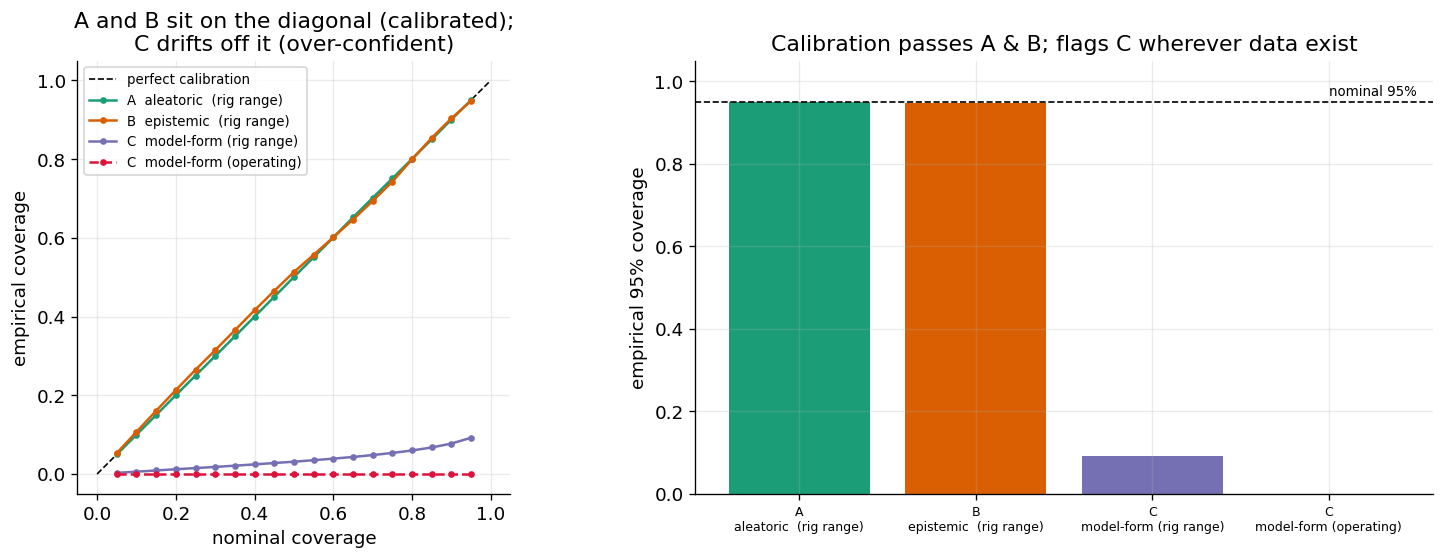

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# ---- reliability diagram ------------------------------------------------
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for name, r, col, ls in results:
    ax1.plot(LEVELS, r["emp"], marker="o", ms=3, color=col, ls=ls, label=name)
ax1.set_xlabel("nominal coverage")
ax1.set_ylabel("empirical coverage")
ax1.set_title("A and B sit on the diagonal (calibrated);\nC drifts off it (over-confident)")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_aspect("equal")

# ---- coverage bar -------------------------------------------------------
names = [r[0].replace("  ", "\n", 1) for r in results]
covs  = [r[1]["cov95"] for r in results]
cols  = [r[2] for r in results]
ax2.bar(range(len(covs)), covs, color=cols)
ax2.axhline(0.95, color="k", ls="--", lw=1)
ax2.text(len(covs)-0.5, 0.965, "nominal 95%", ha="right", fontsize=8)
ax2.set_xticks(range(len(covs))); ax2.set_xticklabels(names, fontsize=7.5)
ax2.set_ylabel("empirical 95% coverage")
ax2.set_title("Calibration passes A & B; flags C wherever data exist")
ax2.set_ylim(0, 1.05)
fig.tight_layout()
plt.show()

## 8. Takeaways

1. **A prediction interval is a claim conditioned on assumptions, not a measured fact.** The
   same nominal $\pm1.5$ meant *irreducible noise* (A) or *fixable data-starvation* (B)
   depending only on which uncertainty you accounted for.

2. **Equal width $\neq$ equal meaning $\neq$ equal decision.** A and B were numerically
   identical yet demanded opposite actions — *redesign* vs *go measure more*. Always ask a
   reported interval: *is this reducible?*

3. **The most dangerous interval is the confident, narrow, wrong one.** Case C omitted
   **model-form uncertainty** and reported only sensor precision. It was the *tightest*
   interval on the page and the only *unsafe* one. Narrow is not the same as good.

4. **Calibration is necessary but not sufficient.** Coverage, NLL and ECE verify that
   reported uncertainty *matches observed error frequencies* — a check you should always run.
   But (a) they only test the distribution you *give* them, so in-domain calibration can hide
   an out-of-domain model-form failure; and (b) even a *perfectly* calibrated interval **does
   not reveal which source** it represents, so it cannot, by itself, tell you whether to
   trust the number, shrink it with data, or distrust it entirely.

> **Report the number *and* its provenance.** State which uncertainty sources are inside your
> interval — aleatoric, epistemic, model-form — because that is what turns an error bar into
> an engineering decision.

---
*Try it yourself:*
- Give **Case B** more points (grow the `xB` array) and watch its interval — and its
  decision — converge onto Case A's: epistemic uncertainty is the reducible kind.
- Shrink the curvature `0.15` in `f_true` toward `0`. Now the straight-line model **fits the
  rig range well**, so C's *in-range* calibration passes — yet it is still wrong at
  $x_\star=11$. That is the dangerous case where calibration cannot warn you.